<a href="https://colab.research.google.com/github/navap3206-debug/hello-world/blob/main/A02_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CARLOS SANTIAGO NAVA PULIDO

#***MANIPULACIÓN DE DATOS PARA MODELADO (ESCALAMIENTO)***

**BASE DE DATOS**: Boston Housing Dataset 1978.xlsx


IMPORTAMOS LOS DATOS

In [183]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from google.colab import files
import pandas as pd



In [184]:
files = files.upload()



Saving Boston Housing Dataset 1978.xlsx to Boston Housing Dataset 1978 (3).xlsx


In [185]:
FILE = 'Boston Housing Dataset 1978 (1).xlsx'
raw_df = pd.read_excel(FILE)

ANALIZAMOS LOS DATOS EDA

In [186]:
raw_df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,452.000000
mean,1.269195,13.295257,9.205158,0.140765,1.101175,15.679800,58.744660,6.173308,78.063241,339.317787,42.614980,332.791107,11.537806,23.750442
std,2.399207,23.048697,7.169630,0.312765,1.646991,27.220206,33.104049,6.476435,203.542157,180.670077,87.585243,125.322456,6.064932,8.808602
min,0.000000,0.000000,0.000000,0.000000,0.385000,3.561000,1.137000,1.129600,1.000000,20.200000,2.600000,0.320000,1.730000,6.300000
25%,0.049443,0.000000,3.440000,0.000000,0.449000,5.961500,32.000000,2.430575,4.000000,254.000000,17.000000,364.995000,6.877500,18.500000
50%,0.144655,0.000000,6.960000,0.000000,0.538000,6.322500,65.250000,3.925850,5.000000,307.000000,18.900000,390.660000,10.380000,21.950000
75%,0.819623,18.100000,18.100000,0.000000,0.647000,6.949000,89.975000,6.332075,24.000000,403.000000,20.200000,395.615000,15.015000,26.600000
max,9.966540,100.000000,27.740000,1.000000,7.313000,100.000000,100.000000,24.000000,666.000000,711.000000,396.900000,396.900000,34.410000,50.000000


In [187]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     452 non-null    float64
dtypes: float64(13), int64(1)
memory usage: 55.5 KB


In [188]:
raw_df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


CONSEGUIMOS EL RANGO (POR CADA ELEMENTO)




In [189]:
rango = raw_df.max() - raw_df.min()
rango[:]

,0
CRIM,9.96654
ZN,100.00000
INDUS,27.74000
CHAS,1.00000
NOX,6.92800
RM,96.43900
AGE,98.86300
DIS,22.87040
RAD,665.00000
TAX,690.80000


ESCALAMOS (0-1)...

In [190]:
min_values = raw_df.min()
max_values = raw_df.max()

#cADA ELEMENTO DE LA DF LE RESTAMOS EL VALOR MINIMO Y DIVIDIMOS SU RANGO
normal_df = (raw_df - min_values) / (rango)


#COMPROBAMOS
print(normal_df.head())




       CRIM    ZN     INDUS  CHAS       NOX        RM       AGE       DIS  \
0  0.000634  0.18  0.083273   0.0  0.022084  0.031253  0.647998  0.129442   
1  0.002740  0.00  0.254867   0.0  0.012125  0.029656  0.786573  0.167793   
2  0.002738  0.00  0.254867   0.0  0.012125  0.037578  0.606526  0.167793   
3  0.003248  0.00  0.078587   0.0  0.010537  0.035639  0.451767  0.215676   
4  0.006928  0.00  0.078587   0.0  0.010537  0.037184  0.536733  0.215676   

        RAD       TAX   PTRATIO         B     LSTAT      MEDV  
0  0.000000  0.399247  0.032209  1.000000  0.099449  0.405034  
1  0.001504  0.321077  0.038549  1.000000  0.226744  0.350114  
2  0.001504  0.321077  0.038549  0.989737  0.070379  0.649886  
3  0.003008  0.292125  0.040832  0.994276  0.037026  0.620137  
4  0.003008  0.292125  0.040832  1.000000  0.110159  0.684211  


In [191]:
print(normal_df.describe())

             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     0.127346    0.132953    0.331837    0.140765    0.103374    0.125663   
std      0.240726    0.230487    0.258458    0.312765    0.237730    0.282253   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.004961    0.000000    0.124009    0.000000    0.009238    0.024891   
50%      0.014514    0.000000    0.250901    0.000000    0.022084    0.028635   
75%      0.082237    0.181000    0.652487    0.000000    0.037818    0.035131   
max      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   

              AGE         DIS         RAD         TAX     PTRATIO           B  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     0.582702    0.220534    0.115885    0.461954    0.101484    0.838346   
std      0.334848    0.2831

ESCALAMIENTO ESTANDAR (Z)

In [192]:
#cADA ELEMENTO DE LA DF LE RESTAMOS EL VALOR MINIMO Y DIVIDIMOS SU RANGO
normal_df = (raw_df - raw_df.mean()) / (raw_df.std())


#COMPROBAMOS
print(normal_df.head())

       CRIM        ZN     INDUS      CHAS       NOX        RM       AGE  \
0 -0.526372  0.204122 -0.961717 -0.450065 -0.341942 -0.334487  0.195002   
1 -0.517623 -0.576833 -0.297806 -0.450065 -0.383837 -0.340144  0.608848   
2 -0.517632 -0.576833 -0.297806 -0.450065 -0.383837 -0.312077  0.071150   
3 -0.515514 -0.576833 -0.979850 -0.450065 -0.390515 -0.318947 -0.391029   
4 -0.500226 -0.576833 -0.979850 -0.450065 -0.390515 -0.313473 -0.137284   

        DIS       RAD       TAX   PTRATIO         B     LSTAT      MEDV  
0 -0.321675 -0.378611 -0.239762 -0.311867  0.511552 -1.081266  0.028331  
1 -0.186246 -0.373698 -0.538649 -0.283324  0.511552 -0.395356 -0.244130  
2 -0.186246 -0.373698 -0.538649 -0.283324  0.479075 -1.237904  1.243053  
3 -0.017156 -0.368785 -0.649348 -0.273048  0.493438 -1.417626  1.095470  
4 -0.017156 -0.368785 -0.649348 -0.273048  0.511552 -1.023557  1.413341  


In [195]:
normal_df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,5.060000e+02,5.060000e+02,5.060000e+02,506.000000,5.060000e+02,5.060000e+02,5.060000e+02,506.000000,5.060000e+02,5.060000e+02,506.000000,5.060000e+02,5.060000e+02,4.520000e+02
mean,1.123388e-16,6.319056e-17,2.527622e-16,0.000000,-2.808469e-17,-2.808469e-17,1.404235e-17,0.000000,-5.616939e-17,-7.021173e-17,0.000000,-3.931857e-16,-4.388233e-17,-1.571997e-17
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1.000000e+00,1.000000e+00,1.000000,1.000000e+00,1.000000e+00,1.000000e+00
min,-5.290063e-01,-5.768333e-01,-1.283910e+00,-0.450065,-4.348387e-01,-4.452134e-01,-1.740200e+00,-0.778778,-3.786107e-01,-1.766301e+00,-0.456869,-2.652925e+00,-1.617134e+00,-1.981068e+00
25%,-5.083984e-01,-5.768333e-01,-8.041082e-01,-0.450065,-3.959800e-01,-3.570252e-01,-8.078969e-01,-0.577900,-3.638718e-01,-4.722298e-01,-0.292458,2.569683e-01,-7.684021e-01,-5.960586e-01
50%,-4.687134e-01,-5.768333e-01,-3.131484e-01,-0.450065,-3.419420e-01,-3.437630e-01,1.965119e-01,-0.347021,-3.589588e-01,-1.788774e-01,-0.270765,4.617600e-01,-1.909018e-01,-2.043959e-01
75%,-1.873840e-01,2.084605e-01,1.240628e+00,-0.450065,-2.757607e-01,-3.207470e-01,9.433994e-01,0.024515,-2.656120e-01,3.524779e-01,-0.255922,5.012980e-01,5.733277e-01,3.234971e-01
max,3.625091e+00,3.761807e+00,2.585188e+00,2.747221,3.771621e+00,3.097706e+00,1.246232e+00,2.752547,2.888526e+00,2.057243e+00,4.045031,5.115515e-01,3.771220e+00,2.979991e+00


ESCALAMIENTO ESTANDAR

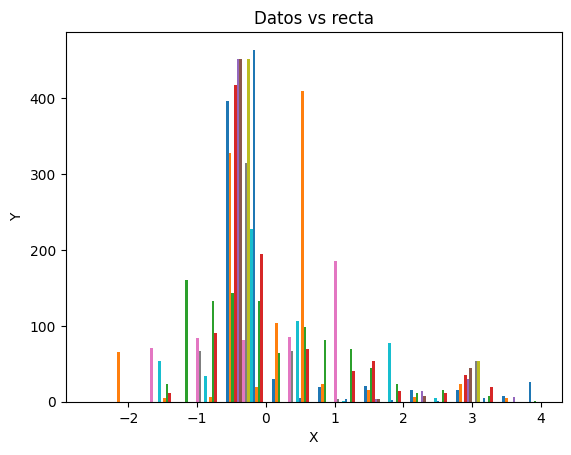

In [194]:
import matplotlib.pyplot as plt


plt.hist(normal_df)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Datos escalados")

plt.show()